# Exercises

---

## Exercise 1: structured and ustructured images
Write a function that outputs the number of PC you have to choose to retain a given percentage of explained variance.
Use this funtion on the  handwritten digit data, and plot the number of PC needed to retain a certain fraction of EVR, for a few vaules of EVR.

Compare this curve to the one you can obtain in unstructured images: either generate images with the same shape of our data or randomly permute the pixels in each image independenlty. How does the number of PC needed to retain a certain fraction of the variance in this case compare to the number needed for digit images?

        As we learned from the lecture, PCA captures the structure of data by finding directions of maximal variance. When this data is structured, which is the case for our digit images, only a small number of PCs is needed to explain a large portion of the total variance. we can also see this in our plot below, as we need fewer PC for the digit images to retain the same EVR compared to images that are unstructured. In the case of unstructured images, the pixel structure is more random, and you need more components to reach the same EVR, as there is no pattern that PCA can use to compress the data effectively. The fact that the curve for the digit data is also nonlinear (as compared to the unstructured data curve) shows that the first few PCs explain most of the variance already, which is not the case for the unstructred data, as the variance is spread out more uniformly across all of the components. No small combination of PCs can capture a significant amount of structure in thsi data. In conclusion, structured data has a lower dimensionality and needs fewer PC to explain a large amount of the variance, while unstructured data is essentially high-dimensional noise in PCA.

In [24]:
import numpy as np
from scipy import io
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pylab as plt
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath("code"))
from utils import download_data

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})

In [25]:
# download lesson data
download_data('https://surfdrive.surf.nl/files/index.php/s/uh8XZNenSfuR2fq')

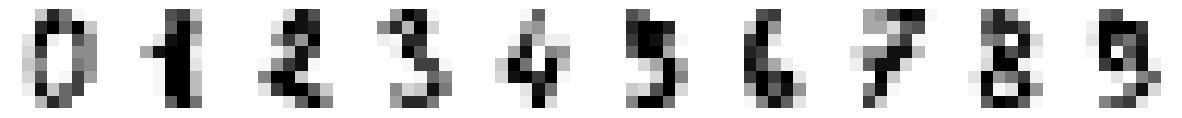

In [26]:
# load image data
dataset = load_digits()
images = dataset.data

#plot first 10 images
plt.figure(figsize=(15,7))
for i,img in enumerate(images[:10]):
    plt.subplot(1,10,i+1)
    plt.imshow(img.reshape(8,8),cmap=plt.cm.Greys)
    plt.axis('off')

In [27]:
# defines a scaler objects
scaler = StandardScaler()
# z-score with fit_transform method
X =scaler.fit_transform(images)

Text(0, 0.5, 'PC2')

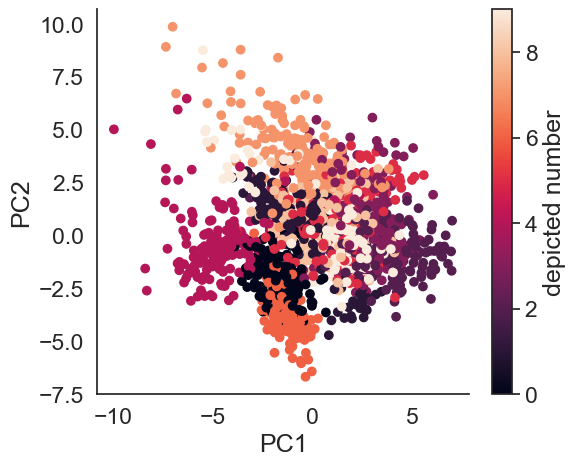

In [28]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)
plt.figure(figsize=(6,5))
plt.scatter(X_2d[:,0],X_2d[:,1],c=dataset.target)
plt.colorbar(label='depicted number')
plt.xlabel('PC1')
plt.ylabel('PC2')

In [34]:
#function to get number of PCs to get certain percentage of EVR

def num_components_for_evr(pca, pct_evr):
    cumulative_evr = np.cumsum(pca.explained_variance_ratio_)
    return np.searchsorted(cumulative_evr, pct_evr) + 1

In [ ]:
#run the function on the digits dataset
evr_pct = [0.5, 0.7, 0.8, 0.9, 0.95, 0.99]

# Fit PCA on digits
pca_digits = PCA()
pca_digits.fit(X)

pcs_needed_digits = [num_components_for_evr(pca_digits, evr) for evr in evr_pct]

In [36]:
#randomly permute pixels in each image (unstructured version)
X_unstructured = X.copy()
np.random.seed(42)
for i in range(X_unstructured.shape[0]):
    np.random.shuffle(X_unstructured[i])

pca_unstructured = PCA()
pca_unstructured.fit(X_unstructured)
pcs_needed_unstructured = [num_components_for_evr(pca_unstructured, evr) for evr in evr_pct]

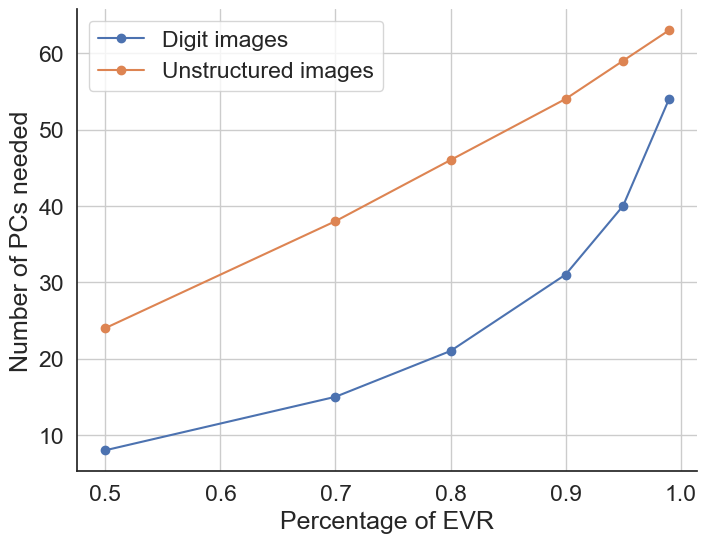

In [37]:
#plot number of PCs vs. percentage of EVR for digit images, as well as the unstructured images
plt.figure(figsize=(8,6))
plt.plot(evr_targets, pcs_needed_digits, label='Digit images', marker='o')
plt.plot(evr_targets, pcs_needed_unstructured, label='Unstructured images', marker = 'o')
plt.xlabel('Percentage of EVR')
plt.ylabel('Number of PCs needed')
plt.legend()
plt.grid(True)
plt.show()